
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
medical_df = pd.read_csv('medical-charges.csv')

In [2]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1. Подивитись кореляцію між ознаками
2. Зробити прогроз на основі даних, які кореліють з charges
3. Побудувати лінії прогнозу для кожної з цих ознак і вивести спільну формулу

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [3]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

Більшість значень знаходяться в інтервалі 0-15000. Хоча медіани майже однакові, чоловіки частіше мають більше значення charges.

In [4]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   color_discrete_sequence=['green', 'grey', 'blue', 'yellow'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

Розподіл витрат на страхування по регіонах не рівномірний. Найбільшу медіану має northeast, найнижчу southwest. Southeast має найбільший розкид до викидів. Ціна на страхування залежить від регіону.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [5]:
px.histogram(medical_df, x='smoker', color='region', title='Smoker')

Найбільше курців знаходиться в регіоні southeast. Серед некурців кількість людей майже однакова по регіонах.

In [6]:
px.histogram(medical_df, x='smoker', color='children', title='Smoker')

Чим більше дітей, тим менша кількість клієнтів з цієї кількістю дітей. Виглядає так, що розподіл кількості курців по кількості дітей пропорційний до некуців.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [7]:
fix_children = px.violin(medical_df,
          x='children',
          y='charges')

fix_children.show()

Люди без дітей мають найбільий розкид на найбільшу кількість викидів.Ті, у кого 5 дітей мають найменший розкид на найвищий мінімум. Найнижчу медіану мають люди з 1 дитиною, а найвищу - з 4 дітьми.

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [8]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [9]:
def estimate_charges(age, w, b):
    return w * age + b

In [10]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

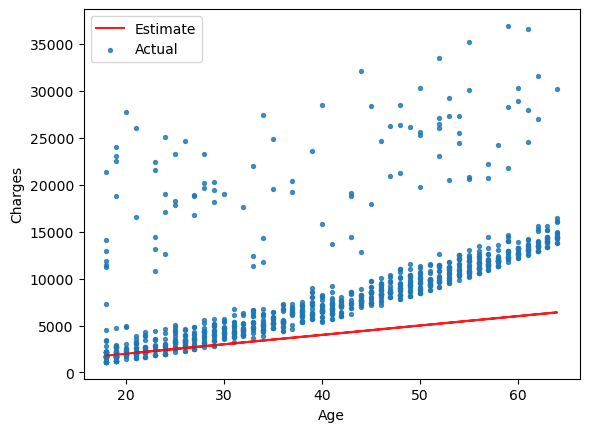

In [11]:
try_parameters(non_smoker_df, 100, 0)

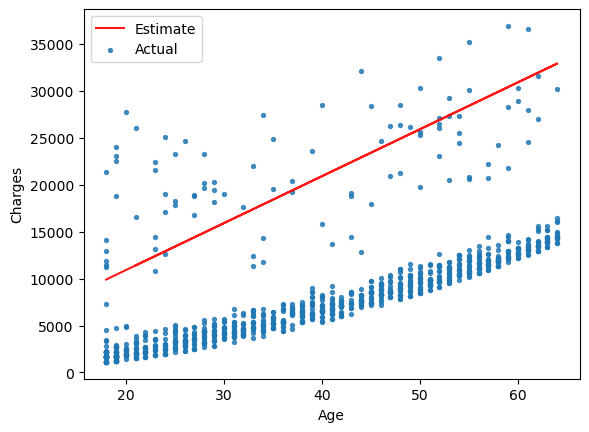

In [12]:
try_parameters(non_smoker_df, 500, 900)

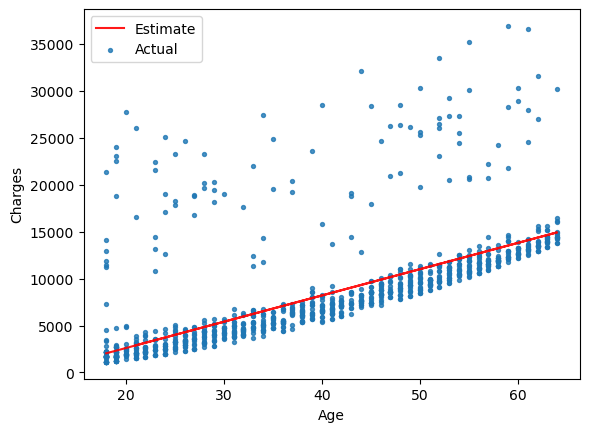

In [13]:
try_parameters(non_smoker_df, 280, -3000)

Перша спроба не відповідає реальному нахилу. В другій спробі нахил більший і не проходить через реальну кількість клієнтів. В третій спробі нахил більш сходий на реальний і знаходиться на лінії клієнтів, які платять менше.

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [14]:
def rmse(df, column_target, column_predictions, w, b):
  targets = df[column_target]
  predictions = estimate_charges(df[column_predictions], w, b)
  loss = np.sqrt(np.mean(np.square(targets - predictions)))
  std = np.std(df[column_target])
  print
  print("RMSE Loss: ", loss)
  print("STD: ", std)

In [15]:
rmse(non_smoker_df, 'charges', 'age', 100, 0 )

RMSE Loss:  6891.549037717145
STD:  5990.964530287611


In [16]:
rmse(non_smoker_df, 'charges', 'age', 500, 900 )

RMSE Loss:  13427.598140733126
STD:  5990.964530287611


In [17]:
rmse(non_smoker_df, 'charges', 'age', 280, -3000 )

RMSE Loss:  4683.622287033994
STD:  5990.964530287611


Найнижче значення, яке мені вдалося досягти RMSE Loss:  4683. Методом проб та помилок потрібно знаходити якнайнижче значення RMSE Loss, перевіряючи спочатку на графіку.